# **Notebook: Double Descent**

Nombre:

Numero de estudiante:

---

Esta notebook investiga el fenómeno **double descent** que ocurre en las Redes Neuronales.

En el aprendizaje automático, a menudo esperamos que a medida que la capacidad de un modelo (por ejemplo, el número de parámetros) aumenta, el error de entrenamiento disminuya y el error de prueba eventualmente aumente después de cierto punto (el clásico "overfitting"). Sin embargo, el fenómeno de Double Descent desafía esta intuición al mostrar que, en ciertos escenarios, a medida que la capacidad del modelo continúa aumentando más allá del punto de overfitting, el error de prueba puede volver a disminuir.

En esta notebook:

- Utilizamos el dataset MNIST-1D que se puede encontrar en https://github.com/greydanus/mnist1d.
- Entrenamos redes con diferentes capacidades (variando el número de unidades ocultas)
- Analizamos cómo el ruido en las etiquetas del conjunto de entrenamiento influye en la forma de la curva Double Descent.

## Dataset

In [28]:
# Instalar el dataset MNIST 1D
!pip install git+https://github.com/greydanus/mnist1d

  Cloning https://github.com/greydanus/mnist1d to /tmp/pip-req-build-x3u11hhs
  Running command git clone --filter=blob:none --quiet https://github.com/greydanus/mnist1d /tmp/pip-req-build-x3u11hhs
  Resolved https://github.com/greydanus/mnist1d to commit 7878d96082abd200c546a07a4101fa90b30fdf7e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [29]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
import mnist1d
import random
random.seed(0)

DEVICE = str(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
print('Using:', DEVICE)

Using: cuda


In [30]:
def get_noisy_mnist1d_dataset(noise_rate=0.0):
    """
    Generates the MNIST-1D dataset with a specified amount of noise in the training labels.

    Args:
        noise_rate (float): The proportion of training labels to flip randomly.

    Returns:
        dict: A dictionary containing the noisy dataset.
    """
    args = mnist1d.data.get_dataset_args()
    args.num_samples = 8000
    args.train_split = 0.5
    args.corr_noise_scale = 0.25
    args.iid_noise_scale = 2e-2
    data = mnist1d.data.get_dataset(args, path='./mnist1d_data.pkl',
                                    download=False, regenerate=True)

    # Add noise to training labels
    for c_y in range(len(data['y'])):
        random_number = random.random()
        if random_number < noise_rate:
            random_int = int(random.random() * 10)
            data['y'][c_y] = random_int

    return data

In [31]:
data = get_noisy_mnist1d_dataset(noise_rate=0.0)

# The training and test input and outputs are in
# data['x'], data['y'], data['x_test'], and data['y_test']
print("Examples in training set: {}".format(len(data['y'])))
print("Examples in test set: {}".format(len(data['y_test'])))
print("Dimensionality of each example: {}".format(data['x'].shape[-1]))

Did or could not load data from ./mnist1d_data.pkl. Rebuilding dataset...
Examples in training set: 4000
Examples in test set: 4000
Dimensionality of each example: 40


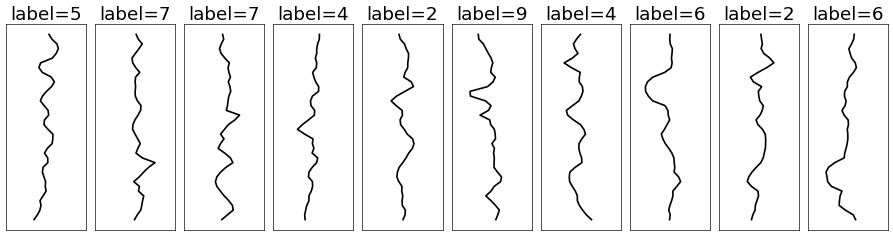

In [32]:
def plot_signals(xs, t, labels=None, ratio=2.6, zoom=1):
    rows, cols = 1, 10
    fig = plt.figure(figsize=[cols*1.5,rows*1.5*ratio], dpi=60)
    for r in range(rows):
        for c in range(cols):
            ix = r*cols + c
            x, t = xs[ix], t
            ax = plt.subplot(rows,cols,ix+1)

            # plot the data
            plt.plot(x, t, 'k-', linewidth=2)
            if labels is not None:
                plt.title("label=" + str(labels[ix]), fontsize=22)

            plt.xlim(-zoom,zoom) ; plt.ylim(-zoom,zoom)
            plt.gca().invert_yaxis() ; plt.xticks([], []), plt.yticks([], [])
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.tight_layout() ; plt.show()
    return fig


# Sample 10 random examples from test
num_test_examples = len(data['y_test'])
sample_indices_test = random.sample(range(num_test_examples), 10)

xs = data['x_test'][sample_indices_test]
labels = data['y_test'][sample_indices_test]
t = data['t']
_ = plot_signals(xs, t, labels=labels, ratio=2.7, zoom=6)

Ahora definiremos la función `get_model`, encargada de construir nuestra red neuronal.

**Tarea:**
Completa la función `get_model` con las siguientes especificaciones:

1. Define las dimensiones:
    * Entrada (D_i): debe coincidir con la dimensionalidad de cada muestra del dataset MNIST-1D.
    * Oculta (n_hidden): se recibe como argumento de la función.
    * Salida (D_o): igual al número de clases.

2. Crea una arquitectura secuencial con las siguientes capas:
    - Capa lineal de entrada.
    - Activación ReLU.
    - Capa lineal oculta.
    - Activación ReLU.
    - Capa lineal de salida.

3. Devuelve el modelo resultante.

In [33]:
def get_model(n_hidden):

  D_i = data['x'].shape[-1]    # Input dimensions
  D_k = n_hidden   # Hidden dimensions
  D_o = len(np.unique(data['y']))    # Output dimensions

  # Modelo estabilizado: BatchNorm y Dropout para reducir picos/oscilaciones
  # Arquitectura: Entrada → Linear → BatchNorm → ReLU → Dropout → Linear → Salida
  model = nn.Sequential(
    nn.Linear(D_i, D_k),
    nn.BatchNorm1d(D_k),
    nn.ReLU(),
    nn.Dropout(p=0.05),
    nn.Linear(D_k, D_o)
  )

  # Move model to appropriate device (CPU/GPU)
  model = model.to(DEVICE)

  # Return the model
  return model

## Entrenamiento y visualización de la curva *Double Descent*

En esta sección vamos a explorar cómo varían el **error de entrenamiento** y el **error de prueba** al aumentar la capacidad de una red neuronal.

**Tu tarea:**

1. Entrena redes neuronales con distintos números de unidades ocultas (`n_hidden`) durante **1000 épocas**, usando los siguientes tamaños de capa oculta:  
   `[2, 10, 26, 45, 48, 50, 55, 70, 120, 200, 250]`.  
2. Registra los errores finales de entrenamiento y prueba para cada modelo.  
3. Grafica los errores en función del número de unidades ocultas para visualizar la **curva de Double Descent**.  
4. Añade una línea vertical que marque el **interpolation threshold**, que se puede representar como el punto en que el número de parámetros del modelo se aproxima al número de ejemplos de entrenamiento. El pico del error de prueba suele aparecer cerca de esta región.

> 💡 **Nota:** la ejecución del código puede tomar un tiempo considerable, ¡así que quizás sea un buen momento para tomar un descanso!


### DATA PREPARATION


In [34]:
X_train = torch.FloatTensor(data['x'])
y_train = torch.LongTensor(data['y'])
X_test = torch.FloatTensor(data['x_test'])
y_test = torch.LongTensor(data['y_test'])

# TensorDataset objects
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# DataLoader instances
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Training samples: 4000
Test samples: 4000
Batch size: 64
Number of training batches: 63
Number of test batches: 63


### FUNCIONES TRAINING Y EVALUATION

In [35]:
def print_log(epoch, train_loss, val_loss):
    print(
        f"Epoch: {epoch + 1:03d} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}"
    )

In [36]:
def train(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    device,
    n_hidden,
    epochs=1000,
    log_fn=print_log,
    log_every=1,
):
    """
    Entrena el modelo utilizando el optimizador y la función de pérdida proporcionados.

    Args:
        model (torch.nn.Module): El modelo que se va a entrenar.
        optimizer (torch.optim.Optimizer): El optimizador que se utilizará para actualizar los pesos del modelo.
        criterion (torch.nn.Module): La función de pérdida que se utilizará para calcular la pérdida.
        train_loader (torch.utils.data.DataLoader): DataLoader que proporciona los datos de entrenamiento.
        val_loader (torch.utils.data.DataLoader): DataLoader que proporciona los datos de validación.
        device (str): El dispositivo donde se ejecutará el entrenamiento.
        patience (int): Número de épocas a esperar después de la última mejora en val_loss antes de detener el entrenamiento (default: 5).
        epochs (int): Número de épocas de entrenamiento (default: 10).
        log_fn (function): Función que se llamará después de cada log_every épocas con los argumentos (epoch, train_loss, val_loss) (default: None).
        log_every (int): Número de épocas entre cada llamada a log_fn (default: 1).

    Returns:
        Tuple[List[float], List[float]]: Una tupla con dos listas, la primera con el error de entrenamiento de cada época y la segunda con el error de validación de cada época.

    """
    epoch_train_errors = []  # colectamos el error de traing para posterior analisis
    epoch_val_errors = []  # colectamos el error de validacion para posterior analisis

    for epoch in range(epochs):  # loop de entrenamiento
        model.train()  # ponemos el modelo en modo de entrenamiento
        train_loss = 0  # acumulador de la perdida de entrenamiento
        for x, y in train_loader:
            x = x.to(device)  # movemos los datos al dispositivo
            y = y.to(device)  # movemos los datos al dispositivo

            optimizer.zero_grad()  # reseteamos los gradientes

            output = model(x)  # forward pass (prediccion)
            batch_loss = criterion(
                output, y
            )  # calculamos la perdida con la salida esperada

            batch_loss.backward()  # backpropagation
            # Gradient clipping para evitar explosiones esporádicas
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()  # actualizamos los pesos

            train_loss += batch_loss.item()  # acumulamos la perdida

        train_loss /= len(train_loader)  # calculamos la perdida promedio de la epoca
        epoch_train_errors.append(train_loss)  # guardamos la perdida de entrenamiento
        val_loss = evaluate(
            model, criterion, val_loader, device
        )  # evaluamos el modelo en el conjunto de validacion
        epoch_val_errors.append(val_loss)  # guardamos la perdida de validacion


        if log_fn is not None:  # si se pasa una funcion de log
            if (epoch + 1) % log_every == 0:  # loggeamos cada log_every epocas
                log_fn(epoch, train_loss, val_loss)  # llamamos a la funcion de log
    return epoch_train_errors, epoch_val_errors

In [37]:
def evaluate(model, criterion, data_loader, device):
    """
    Evalúa el modelo en los datos proporcionados y calcula la pérdida promedio.

    Args:
        model (torch.nn.Module): El modelo que se va a evaluar.
        criterion (torch.nn.Module): La función de pérdida que se utilizará para calcular la pérdida.
        data_loader (torch.utils.data.DataLoader): DataLoader que proporciona los datos de evaluación.

    Returns:
        float: La pérdida promedio en el conjunto de datos de evaluación.

    """
    model.eval()  # ponemos el modelo en modo de evaluacion
    total_loss = 0  # acumulador de la perdida
    with torch.no_grad():  # deshabilitamos el calculo de gradientes
        for x, y in data_loader:  # iteramos sobre el dataloader
            x = x.to(device)  # movemos los datos al dispositivo
            y = y.to(device)  # movemos los datos al dispositivo
            output = model(x)  # forward pass
            total_loss += criterion(output, y).item()  # acumulamos la perdida
    return total_loss / len(data_loader)  # retornamos la perdida promedio

In [38]:
# def train_one_epoch(model, train_loader, criterion, optimizer, device):
#     """
#     Train the model for one epoch.

#     Args:
#         model: Neural network model
#         train_loader: DataLoader for training data
#         criterion: Loss function
#         optimizer: Optimizer
#         device: Device to run on (CPU/GPU)

#     Returns:
#         float: Average training loss for the epoch
#     """
#     model.train()
#     total_loss = 0.0

#     for X_batch, y_batch in train_loader:
#         # Move data to device
#         X_batch = X_batch.to(device)
#         y_batch = y_batch.to(device)

#         # Forward pass
#         outputs = model(X_batch)
#         loss = criterion(outputs, y_batch)

#         # Backward pass
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     return total_loss / len(train_loader)


# def evaluate(model, test_loader, criterion, device):
#     """
#     Evaluate the model on test data.

#     Args:
#         model: Neural network model
#         test_loader: DataLoader for test data
#         criterion: Loss function
#         device: Device to run on (CPU/GPU)

#     Returns:
#         float: Average test loss
#     """
#     model.eval()
#     total_loss = 0.0

#     with torch.no_grad():
#         for X_batch, y_batch in test_loader:
#             # Move data to device
#             X_batch = X_batch.to(device)
#             y_batch = y_batch.to(device)

#             # Forward pass
#             outputs = model(X_batch)
#             loss = criterion(outputs, y_batch)

#             total_loss += loss.item()

#     return total_loss / len(test_loader)




### TRAINING LOOP

In [39]:
hidden_sizes = [2, 10, 26, 45, 48, 50, 55, 70, 120, 200, 250]

# Resultados
train_losses_final = []
test_losses_final = []
train_histories = []
test_histories = []

# Entrenamiento de los modelos con diferentes capacidades
for idx, n_hidden in enumerate(hidden_sizes):
    print(f"\n{'='*60}")
    print(f"MODEL {idx+1}/{len(hidden_sizes)}: n_hidden = {n_hidden}")
    print(f"{'='*60}")

    model = get_model(n_hidden)

    # Inicialización del optimizador y la función de pérdida
    # Weight decay (regularización L2) ayuda a reducir picos y oscilaciones en entrenamientos largos
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
    # Label smoothing para reducir sobreconfianza y picos en validación
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    # Entrenar el modelo usando la función train
    train_loss_history, test_loss_history = train(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=train_loader,
        val_loader=test_loader,
        device=DEVICE,
        n_hidden=n_hidden,
        epochs=6000,
        log_fn=print_log,
        log_every=100
    )

    # Guardar los resultados: última epoch para cada hidden_size
    train_losses_final.append(train_loss_history[-1])
    test_losses_final.append(test_loss_history[-1])
    train_histories.append(train_loss_history)
    test_histories.append(test_loss_history)


MODEL 1/1: n_hidden = 70
Epoch: 100 | Train Loss: 1.14358 | Val Loss: 1.26213
Epoch: 200 | Train Loss: 1.06662 | Val Loss: 1.24963
Epoch: 300 | Train Loss: 1.01217 | Val Loss: 1.25964
Epoch: 400 | Train Loss: 0.98387 | Val Loss: 1.25948
Epoch: 500 | Train Loss: 0.96218 | Val Loss: 1.26526
Epoch: 600 | Train Loss: 0.94862 | Val Loss: 1.26575
Epoch: 700 | Train Loss: 0.93171 | Val Loss: 1.27398
Epoch: 800 | Train Loss: 0.92783 | Val Loss: 1.28079
Epoch: 900 | Train Loss: 0.91099 | Val Loss: 1.28121
Epoch: 1000 | Train Loss: 0.90944 | Val Loss: 1.29052
Epoch: 1100 | Train Loss: 0.89082 | Val Loss: 1.28669
Epoch: 1200 | Train Loss: 0.88589 | Val Loss: 1.28762
Epoch: 1300 | Train Loss: 0.86100 | Val Loss: 1.29430
Epoch: 1400 | Train Loss: 0.86951 | Val Loss: 1.29442
Epoch: 1500 | Train Loss: 0.86355 | Val Loss: 1.28786
Epoch: 1600 | Train Loss: 0.86436 | Val Loss: 1.29400
Epoch: 1700 | Train Loss: 0.84636 | Val Loss: 1.29733
Epoch: 1800 | Train Loss: 0.85645 | Val Loss: 1.29485
Epoch: 1900

### VISUALIZACIONES

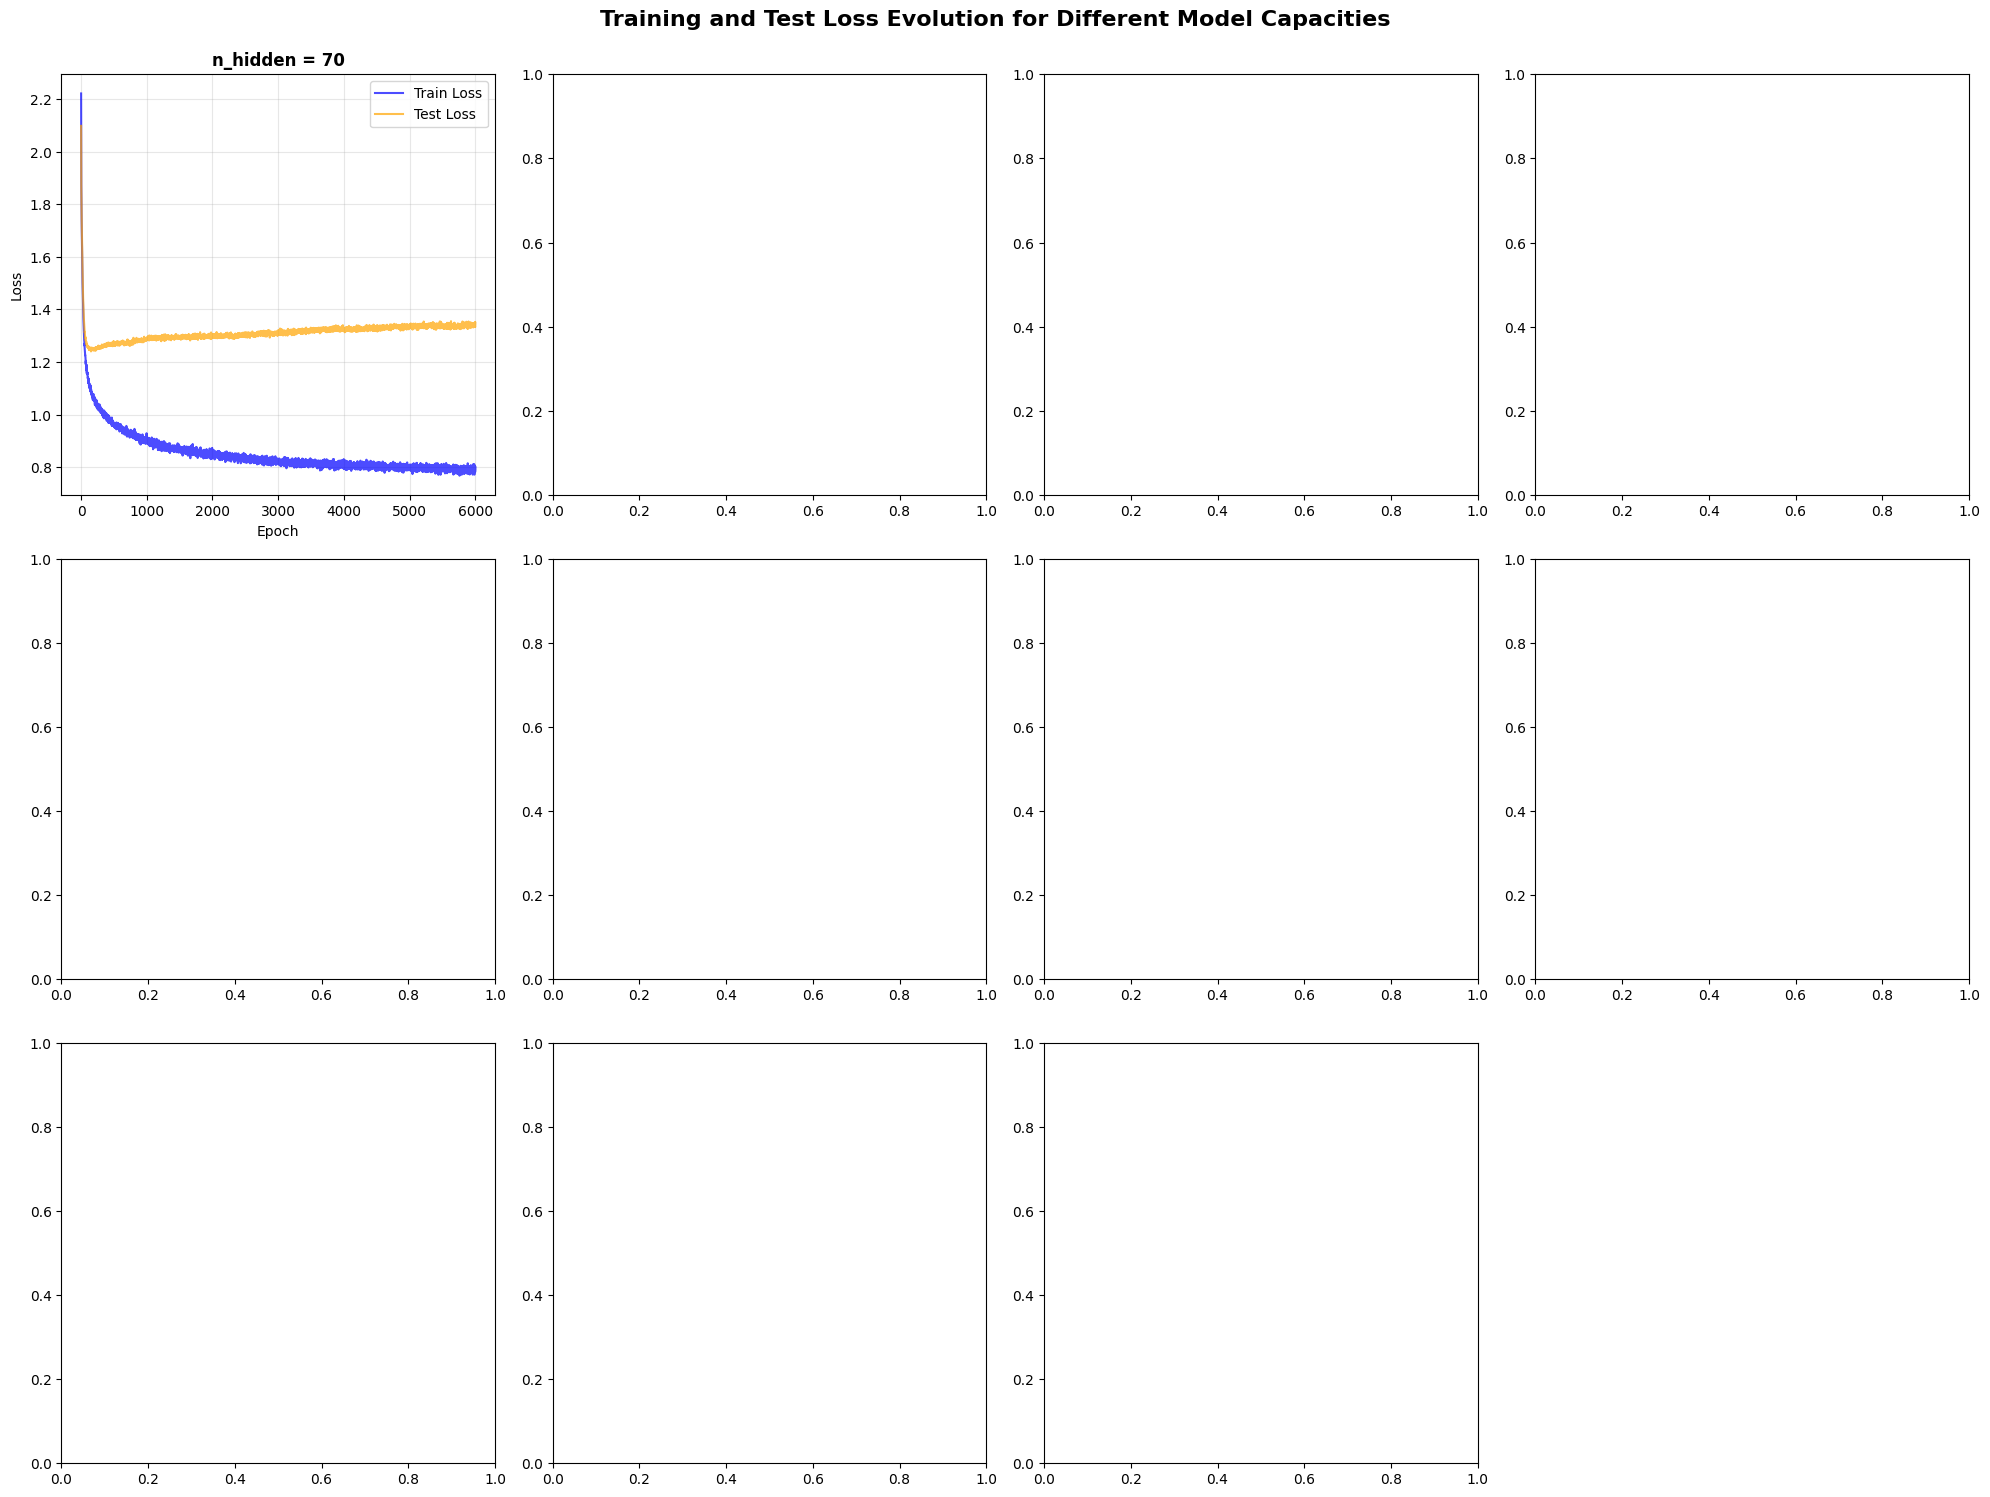

In [40]:

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for idx, n_hidden in enumerate(hidden_sizes):
    ax = axes[idx]
    epochs = range(1, len(train_histories[idx]) + 1)

    # Plot training and test loss
    ax.plot(epochs, train_histories[idx], 'b-', label='Train Loss', alpha=0.7)
    ax.plot(epochs, test_histories[idx], 'orange', label='Test Loss', alpha=0.7)

    ax.set_title(f'n_hidden = {n_hidden}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')

plt.suptitle('Training and Test Loss Evolution for Different Model Capacities',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Explorando el *Double Descent* con etiquetas ruidosas

En esta sección repetiremos el experimento anterior, pero introduciendo **ruido en las etiquetas** del conjunto de entrenamiento para analizar cómo afecta al fenómeno *Double Descent*.

Entrenaremos nuevamente el modelo con los mismos tamaños de capa oculta:  
`[2, 10, 26, 45, 48, 50, 55, 70, 120, 200, 250]`,  
pero esta vez usaremos datasets en los que un porcentaje de las etiquetas ha sido aleatorizado. Realizaremos el experimento con dos niveles de ruido: **10 %** y **30 %**.

Después de entrenar los modelos para cada nivel de ruido, graficaremos las curvas de error de entrenamiento y prueba, similar a como lo hicimos anteriormente.

**Tu tarea:**

1. Ejecuta la celda siguiente para cargar los datasets con **10 %** y **30 %** de ruido.  
2. Adapta el código de entrenamiento y visualización de la sección anterior para entrenar los modelos con los conjuntos ruidosos y graficar los resultados.


In [ ]:
# Carga el dataset MNIST-1D con 10% de ruido en las etiquetas de entrenamiento
data_noisy_10 = get_noisy_mnist1d_dataset(noise_rate=0.10)

# Puedes imprimir información sobre el dataset ruidoso para verificarlo
print("Dataset con 10% de ruido:")
print("Ejemplos en entrenamiento:", len(data_noisy_10['y']))
print("Ejemplos en prueba:", len(data_noisy_10['y_test']))
print("-" * 20)

# Repite el proceso para el 30% de ruido (modificando la tasa de ruido)
data_noisy_30 = get_noisy_mnist1d_dataset(noise_rate=0.30)

print("Dataset con 30% de ruido:")
print("Ejemplos en entrenamiento:", len(data_noisy_30['y']))
print("Ejemplos en prueba:", len(data_noisy_30['y_test']))

Did or could not load data from ./mnist1d_data.pkl. Rebuilding dataset...
Dataset con 10% de ruido:
Ejemplos en entrenamiento: 4000
Ejemplos en prueba: 4000
--------------------
Did or could not load data from ./mnist1d_data.pkl. Rebuilding dataset...
Dataset con 30% de ruido:
Ejemplos en entrenamiento: 4000
Ejemplos en prueba: 4000


### 10% NOISE

In [ ]:
# Preparación DataLoaders con 10% noise
X_train_10 = torch.FloatTensor(data_noisy_10['x'])
y_train_10 = torch.LongTensor(data_noisy_10['y'])
X_test_10 = torch.FloatTensor(data_noisy_10['x_test'])
y_test_10 = torch.LongTensor(data_noisy_10['y_test'])

train_dataset_10 = TensorDataset(X_train_10, y_train_10)
test_dataset_10 = TensorDataset(X_test_10, y_test_10)

train_loader_10 = DataLoader(train_dataset_10, batch_size=batch_size, shuffle=True)
test_loader_10 = DataLoader(test_dataset_10, batch_size=batch_size, shuffle=False)

# Guardar los resultados de entrenamiento y prueba
train_losses_final_10 = []
test_losses_final_10 = []
train_histories_10 = []
test_histories_10 = []

# Entrenamiento de los modelos con 10% noise
for idx, n_hidden in enumerate(hidden_sizes):
    print(f"\n{'='*60}")
    print(f"MODEL {idx+1}/{len(hidden_sizes)}: n_hidden = {n_hidden} (10% noise)")
    print(f"{'='*60}")

    model = get_model(n_hidden)

    # Inicialización del optimizador y la función de pérdida
    # Weight decay (regularización L2) ayuda a reducir picos y oscilaciones en entrenamientos largos
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
    # Label smoothing para reducir sobreconfianza y picos en validación
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    # Entrenar el modelo usando la función train
    train_loss_history, test_loss_history = train(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=train_loader_10,
        val_loader=test_loader_10,
        device=DEVICE,
        n_hidden=n_hidden,
        epochs=6000,
        log_fn=print_log,
        log_every=100
    )

    # Guardar los resultados: última epoch para cada hidden_size
    train_losses_final_10.append(train_loss_history[-1])
    test_losses_final_10.append(test_loss_history[-1])
    train_histories_10.append(train_loss_history)
    test_histories_10.append(test_loss_history)


MODEL 1/11: n_hidden = 2 (10% noise)


KeyboardInterrupt: 

### 30% NOISE

In [ ]:
# DataLoaders con 30% noise
X_train_30 = torch.FloatTensor(data_noisy_30['x'])
y_train_30 = torch.LongTensor(data_noisy_30['y'])
X_test_30 = torch.FloatTensor(data_noisy_30['x_test'])
y_test_30 = torch.LongTensor(data_noisy_30['y_test'])

train_dataset_30 = TensorDataset(X_train_30, y_train_30)
test_dataset_30 = TensorDataset(X_test_30, y_test_30)

train_loader_30 = DataLoader(train_dataset_30, batch_size=batch_size, shuffle=True)
test_loader_30 = DataLoader(test_dataset_30, batch_size=batch_size, shuffle=False)

train_losses_final_30 = []
test_losses_final_30 = []
train_histories_30 = []
test_histories_30 = []

# Entrenamiento de los modelos con 30% noise
for idx, n_hidden in enumerate(hidden_sizes):
    print(f"\n{'='*60}")
    print(f"MODEL {idx+1}/{len(hidden_sizes)}: n_hidden = {n_hidden} (30% noise)")
    print(f"{'='*60}")

    model = get_model(n_hidden)

    # Inicialización del optimizador y la función de pérdida
    # Weight decay (regularización L2) ayuda a reducir picos y oscilaciones en entrenamientos largos
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
    # Label smoothing para reducir sobreconfianza y picos en validación
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    # Entrenar el modelo usando la función train
    train_loss_history, test_loss_history = train(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=train_loader_30,
        val_loader=test_loader_30,
        device=DEVICE,
        n_hidden=n_hidden,
        epochs=6000,
        log_fn=print_log,
        log_every=100
    )

    # Guardar los resultados: última epoch para cada hidden_size
    train_losses_final_30.append(train_loss_history[-1])
    test_losses_final_30.append(test_loss_history[-1])
    train_histories_30.append(train_loss_history)
    test_histories_30.append(test_loss_history)



MODEL 1/11: n_hidden = 2 (30% noise)


KeyboardInterrupt: 

### VISUALIZATIONS

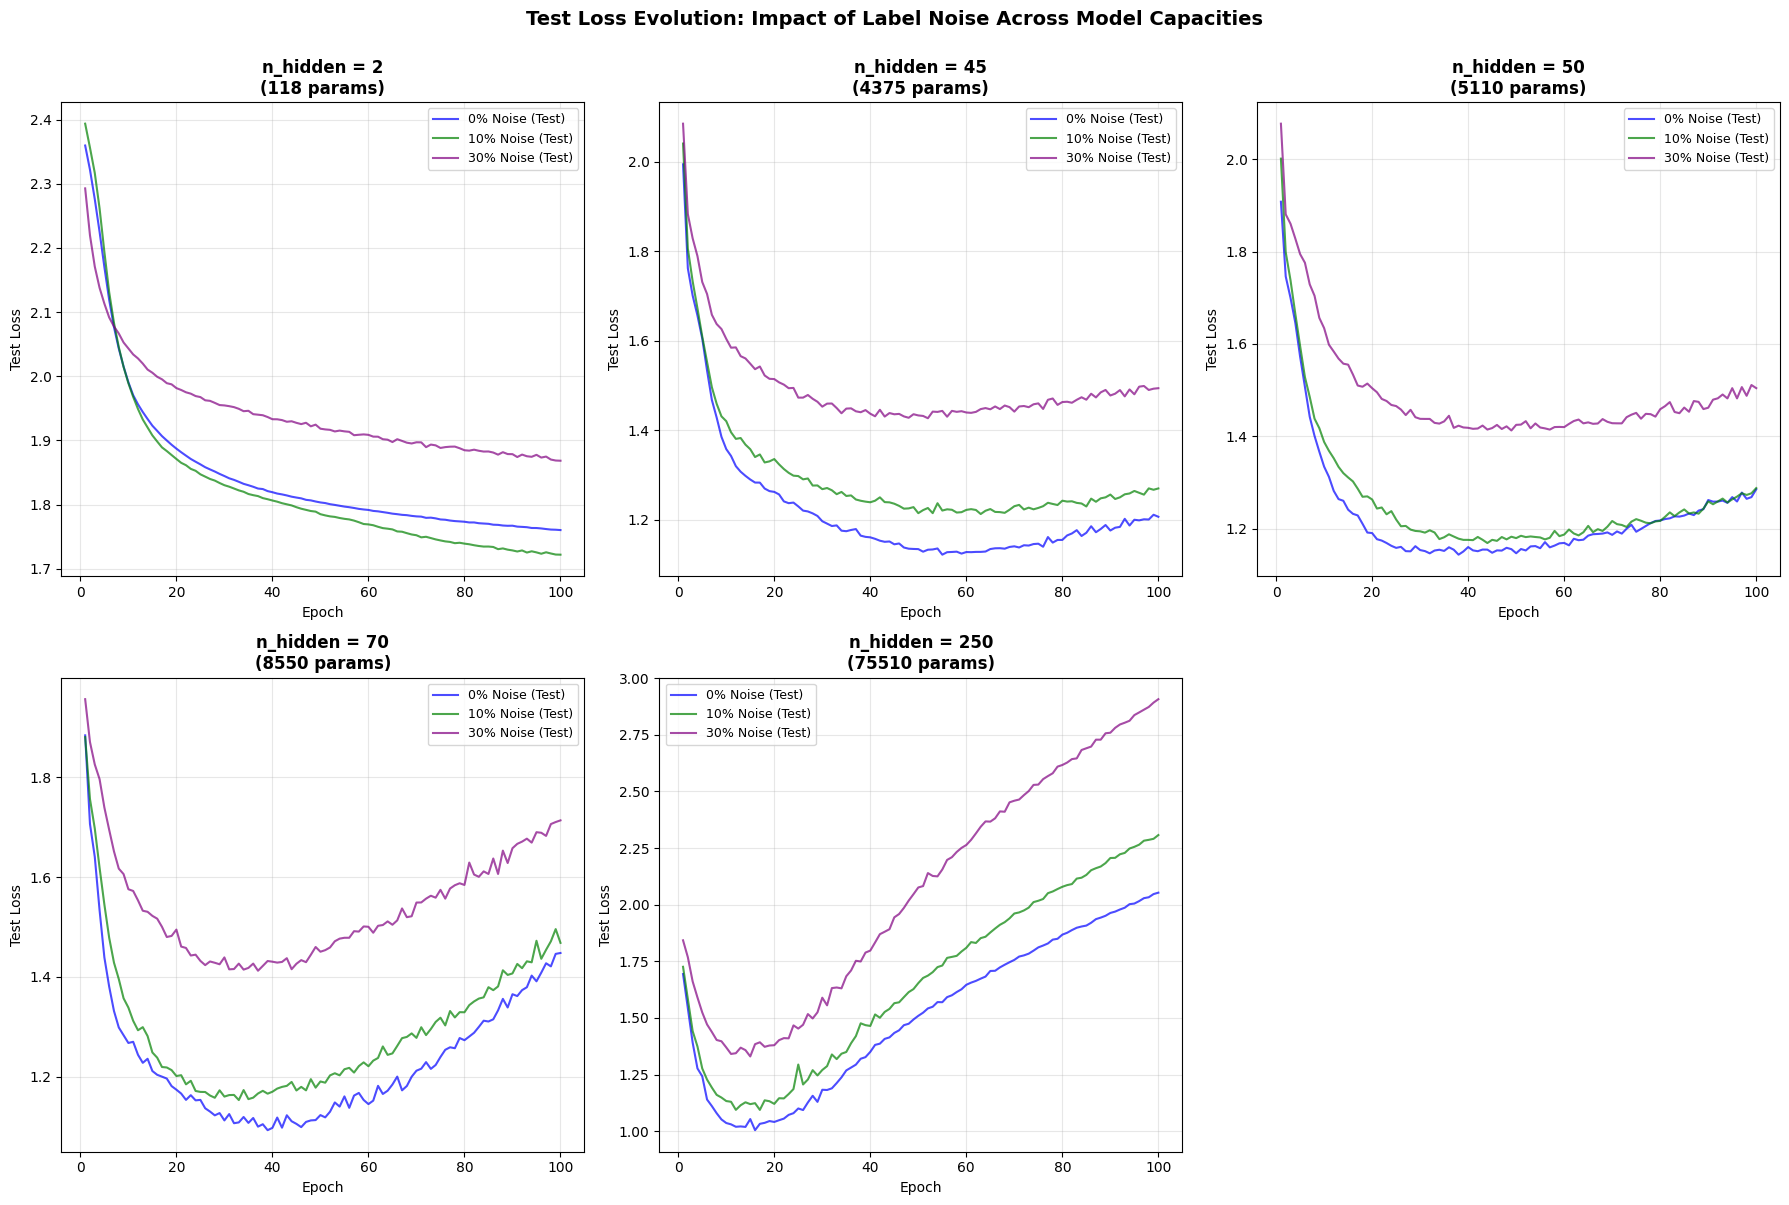

In [ ]:
selected_indices = [0, 3, 5, 7, 10]
selected_sizes = [hidden_sizes[i] for i in selected_indices]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for plot_idx, model_idx in enumerate(selected_indices):
    ax = axes[plot_idx]
    n_hidden = hidden_sizes[model_idx]
    epochs = range(1, num_epochs + 1)

    # Plot test losses en todos los niveles de ruido
    ax.plot(epochs, test_histories[model_idx], 'b-',
            label='0% Noise (Test)', linewidth=1.5, alpha=0.7)
    ax.plot(epochs, test_histories_10[model_idx], 'g-',
            label='10% Noise (Test)', linewidth=1.5, alpha=0.7)
    ax.plot(epochs, test_histories_30[model_idx], color='purple',
            label='30% Noise (Test)', linewidth=1.5, alpha=0.7)

    ax.set_title(f'n_hidden = {n_hidden}\n({num_parameters[model_idx]} params)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')

plt.suptitle('Test Loss Evolution: Impact of Label Noise Across Model Capacities',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Preguntas finales

1. ¿Cómo afecta el **ruido en las etiquetas** al error mínimo de entrenamiento alcanzable? ¿Por qué ocurre esto?  
2. Según tus observaciones, ¿cómo influye el **ruido en las etiquetas** en el fenómeno de *Double Descent*, especialmente en relación con la **capacidad del modelo** y su **capacidad de generalización**?  
3. En *Deep Learning*, ¿es lo mismo el **overfitting** durante el entrenamiento que la **sobreparametrización** de los modelos? Explica las diferencias.
